In [1]:
!pip install decoupler
!pip install scanpy
!pip install leidenalg
!pip install python-igraph
!pip install --user scikit-misc
!pip install -U scvi-tools

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.0/118.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 5.0 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=8e1a4b0688583ca19c2efd5130cb26fe89d3ace2dc0bae047f3cb8a70baedd94
  Stored in directory: /root/.cache/pip/wheels/d6/19/ee/0a6a1793d91c449563b49ccab57ce52da3e6fab76

In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [73]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scvi

# Load your CAF dataset
adata = sc.read("/content/drive/MyDrive/Lab/Figure/GSE165897_EOC_h5ad/GSE165897_EOC_sctour.h5ad")
adata

AnnData object with n_obs × n_vars = 8806 × 28231
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'patient_id', 'treatment_phase', 'anatomical_location', 'cell_type', 'cell_subtype', 'percent.mt', 'score', 'used_in_query', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'total_counts', 'ptime'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'orig_genes', 'umap'
    obsm: 'X_DV', 'X_TNODE', 'X_VF', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'cosine_similarity', 'distances'

# Step 1. Load libraries and CollecTRI network

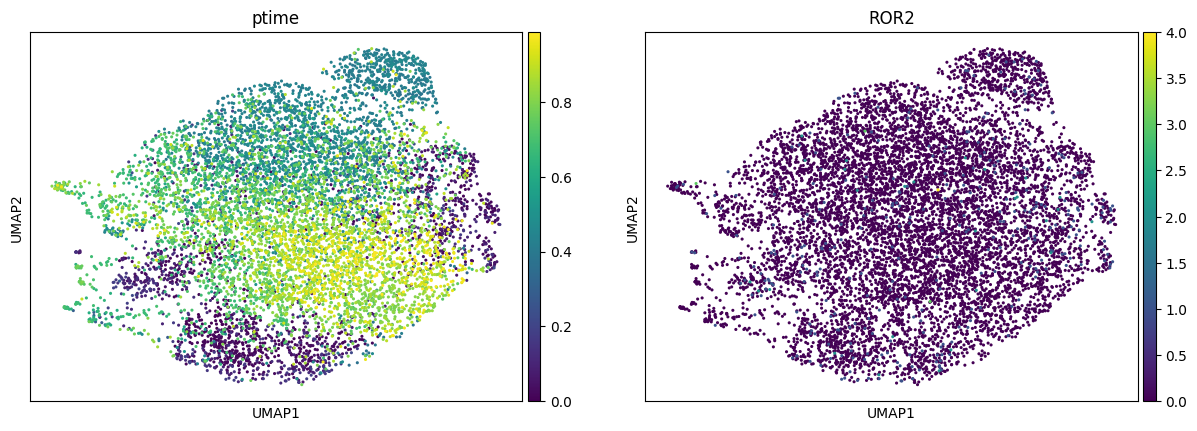

In [5]:
sc.pl.umap(
    adata,
    color=["ptime", "ROR2"],  # cluster labels + your WNT5A assignment
    palette="tab20",
    size=20,
    legend_loc="right"
)

In [6]:
# Fetch CollecTRI TF-target network (human)
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


# Step 2. Run TF activity scoring (ULM = Univariate Linear Model)

In [81]:
dc.mt.ulm(data=adata, net=collectri)

In [82]:
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 8806 × 752
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'patient_id', 'treatment_phase', 'anatomical_location', 'cell_type', 'cell_subtype', 'percent.mt', 'score', 'used_in_query', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'total_counts', 'ptime', 'ptime_bin', 'ROR2_group'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'orig_genes', 'umap'
    obsm: 'X_DV', 'X_TNODE', 'X_VF', 'X_scVI', 'X_umap', 'score_ulm', 'padj_ulm'

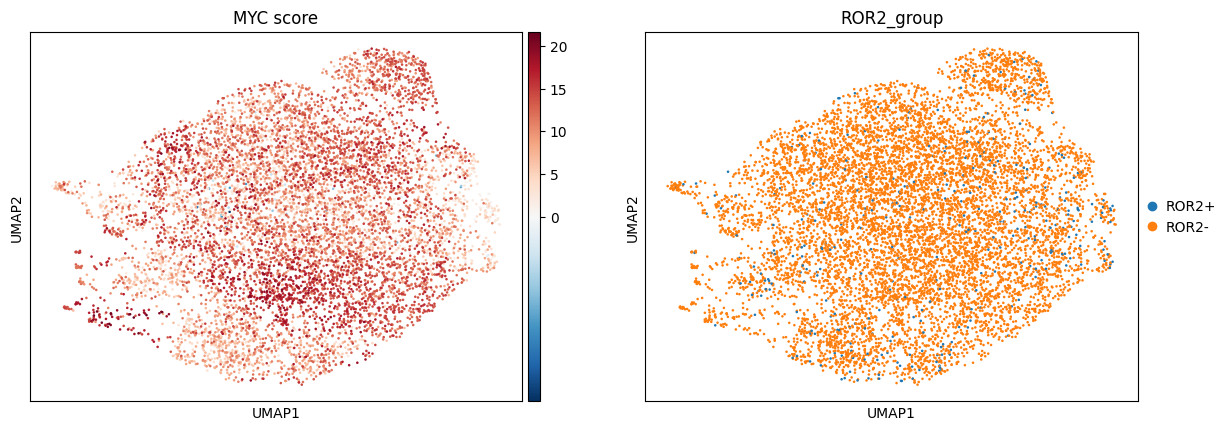

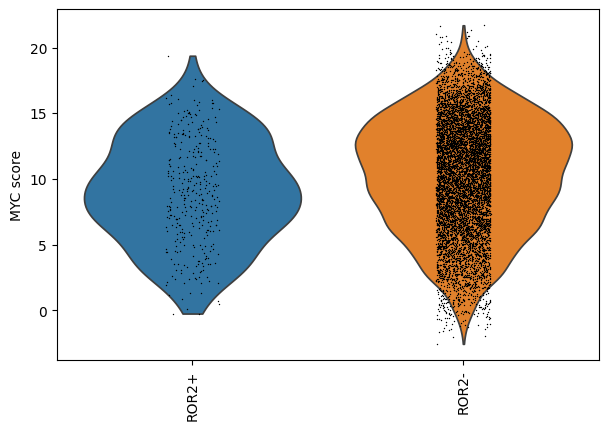

In [83]:
tf = "MYC"
sc.pl.umap(score, color=[tf, "ROR2_group"], cmap="RdBu_r", vcenter=0, title=[f"{tf} score", "ROR2_group"])
sc.pl.violin(score, keys=[tf], groupby="ROR2_group", rotation=90, ylabel=f"{tf} score")

In [85]:
# Identify TFs for each treatment_phase
df = dc.tl.rankby_group(adata=score, groupby="ROR2_group", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
4,ROR2-,rest,SMARCA5,29.016788,0.108943,2.515888e-179,3.783896e-177
5,ROR2-,rest,UBTF,28.994131,0.124501,5.464418e-179,6.848738e-177
13,ROR2-,rest,KAT5,27.158291,0.271057,5.658951e-159,3.039665e-157
15,ROR2-,rest,E4F1,26.663392,0.125608,7.450188e-153,3.501588e-151
19,ROR2-,rest,ZNF362,25.892995,0.227564,5.727845e-145,2.153670e-143
...,...,...,...,...,...,...,...
1494,ROR2+,rest,FOXM1,0.048578,0.002963,9.612731e-01,9.729171e-01
1495,ROR2+,rest,EGR3,0.039148,0.002047,9.687837e-01,9.781605e-01
1497,ROR2+,rest,HDAC3,0.031979,0.001479,9.744982e-01,9.823360e-01
1502,ROR2+,rest,SPDEF,0.013699,0.000387,9.890741e-01,9.903911e-01


# Step 3. Visualize TF activity

In [86]:
# Top 3 TFs for each WNT5A_group
n_markers = 5
source_markers = (
    df.groupby("group")
    .head(n_markers)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

/tmp/ipython-input-1417353166.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipython-input-1417353166.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["name"]


{'ROR2+': ['CDX1', 'ATF1', 'ATF3', 'FOXE1', 'ZFHX3'],
 'ROR2-': ['SMARCA5', 'UBTF', 'KAT5', 'E4F1', 'ZNF362']}

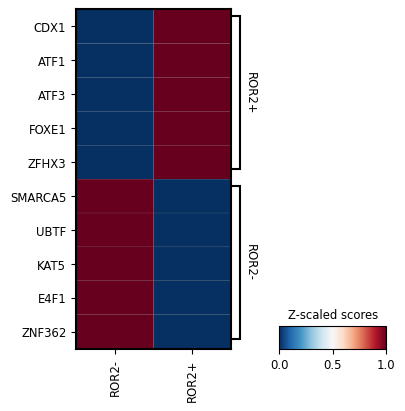

In [87]:
# obtained markers
import scanpy as sc

# Ensure WNT5A_group order is set
score.obs['ROR2_group'] = score.obs['ROR2_group'].astype(
    pd.CategoricalDtype(categories=["ROR2-", "ROR2+"], ordered=True)
)

# Plot heatmap rotated: genes on y-axis
sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,         # TFs of interest
    groupby="ROR2_group",
    dendrogram=False,                 # turn off clustering to preserve order
    standard_scale="var",
    swap_axes=True,
    cmap="RdBu_r",
    colorbar_title="Z-scaled scores",
    figsize=(4, 4),                  # taller figure for gene names
    save="ROR2_group_TF_scores_rotated.pdf"
)


In [88]:
# relevant TFs and target genes
gex_bcells = adata[adata.obs["ROR2_group"] == "ROR2+"].to_df().mean(0).to_frame().T
score_bcells = score[score.obs["ROR2_group"] == "ROR2+"].to_df().mean(0).to_frame().T

dc.pl.network(
    data=gex_bcells,
    score=score_bcells,
    net=collectri,
    sources=['CDX1', 'ATF1', 'ATF3', 'FOXE1', 'ZFHX3'],  # your selected TFs
    targets=7,                     # fewer targets = cleaner
    size_node=10,                  # bigger nodes
    size_label=11,                  # larger text
    layout="fr",                   # better balanced layout
    s_cmap="coolwarm",             # diverging colormap for TF enrichment
    t_cmap="viridis",              # continuous colormap for targets
    vcenter=True,                  # center colors around 0
    c_pos_w="forestgreen",         # softer positive edge color
    c_neg_w="firebrick",           # softer negative edge color
    figsize=(12, 12),              # larger figure
    dpi=600,                       # high-resolution
    save="ROR2_pos_TFs_network_clean.pdf"
)


# Step 4. Pathway Scoring

In [89]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


In [90]:
dc.mt.ulm(data=adata, net=progeny)

In [91]:
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 8806 × 14
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'patient_id', 'treatment_phase', 'anatomical_location', 'cell_type', 'cell_subtype', 'percent.mt', 'score', 'used_in_query', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'total_counts', 'ptime', 'ptime_bin', 'ROR2_group'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'orig_genes', 'umap', 'ROR2_group_colors'
    obsm: 'X_DV', 'X_TNODE', 'X_VF', 'X_scVI', 'X_umap', 'score_ulm', 'padj_ulm'

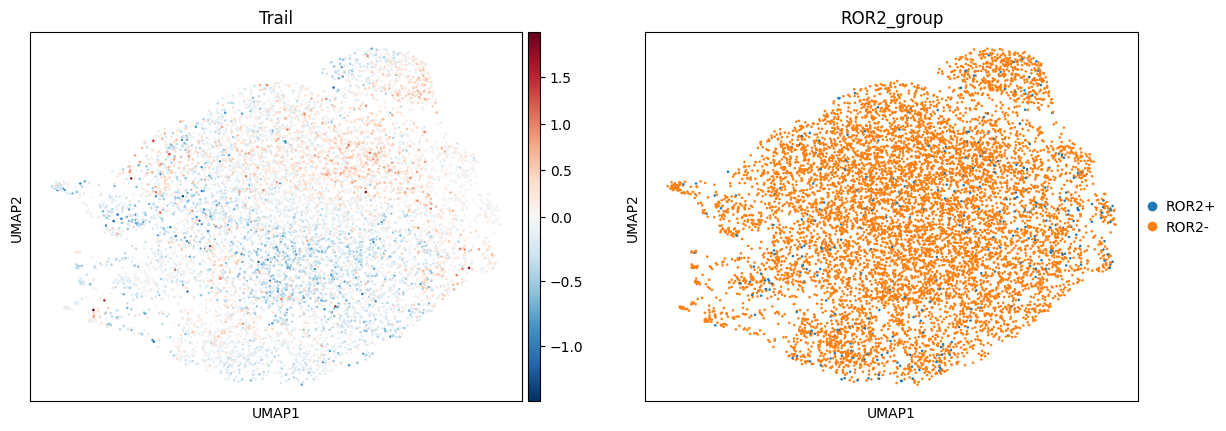

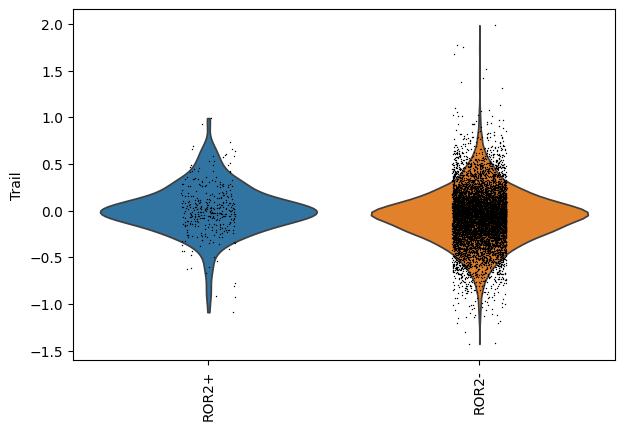

In [92]:
sc.pl.umap(score, color=["Trail", "ROR2_group"], cmap="RdBu_r", vcenter=0)
sc.pl.violin(score, keys=["Trail"], groupby="ROR2_group", rotation=90)

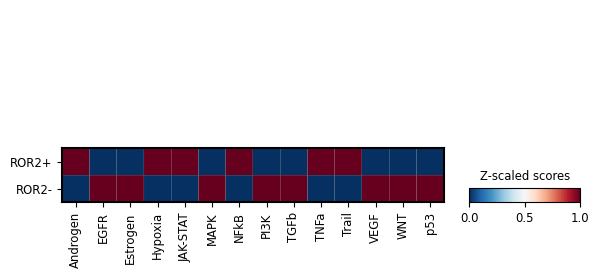

In [93]:
sc.pl.matrixplot(
    adata=score,
    var_names=score.var_names,
    groupby="ROR2_group",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

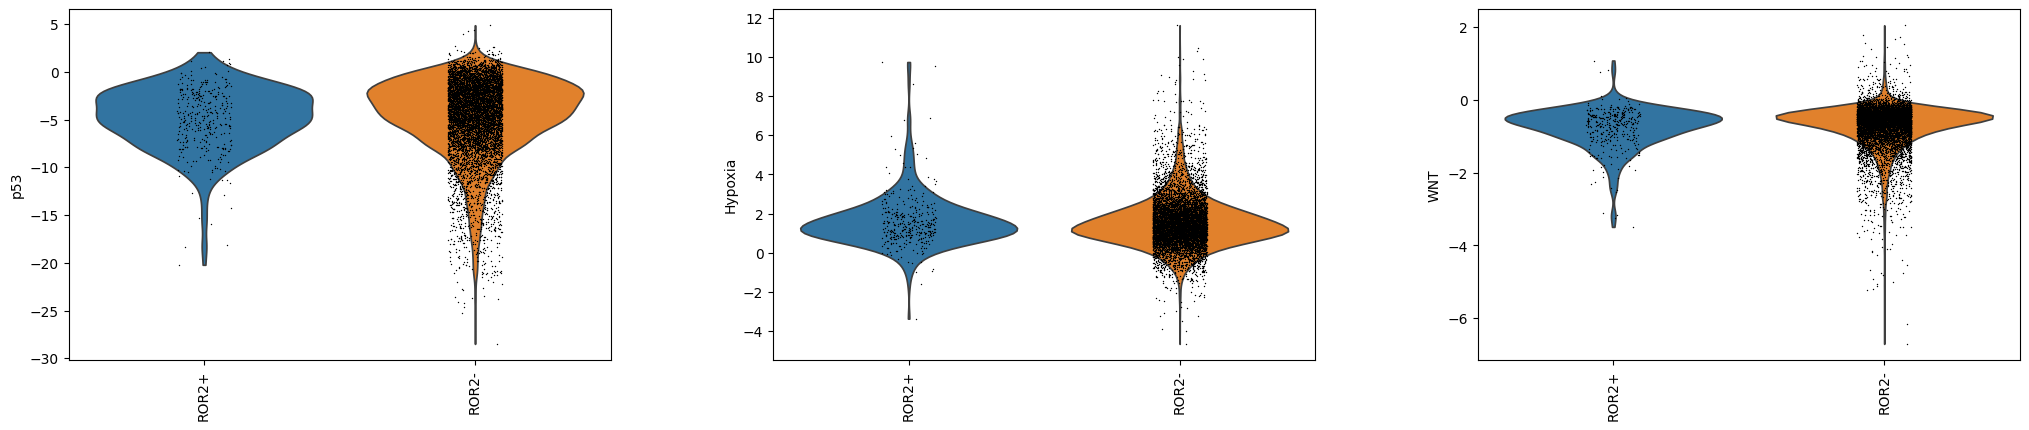

In [95]:
sc.pl.violin(score, keys=["p53", "Hypoxia", "WNT"], groupby="ROR2_group", rotation=90)

# Step 5. Hallmark Gene Sets

In [96]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


In [97]:
dc.mt.ulm(data=adata, net=hallmark)

In [98]:
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 8806 × 50
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'patient_id', 'treatment_phase', 'anatomical_location', 'cell_type', 'cell_subtype', 'percent.mt', 'score', 'used_in_query', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'total_counts', 'ptime', 'ptime_bin', 'ROR2_group'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'orig_genes', 'umap', 'ROR2_group_colors', 'treatment_phase_colors'
    obsm: 'X_DV', 'X_TNODE', 'X_VF', 'X_scVI', 'X_umap', 'score_ulm', 'padj_ulm'

In [99]:
df = dc.tl.rankby_group(adata=score, groupby="ROR2_group", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]
df

,group,reference,name,stat,meanchange,pval,padj
1,ROR2-,rest,NOTCH_SIGNALING,25.567624,0.108956,2.559066e-141,6.397665e-140
2,ROR2-,rest,UNFOLDED_PROTEIN_RESPONSE,20.517022,0.380037,2.021129e-92,3.368549e-91
3,ROR2-,rest,MTORC1_SIGNALING,18.115544,0.369410,1.171625e-72,1.464531e-71
4,ROR2-,rest,PROTEIN_SECRETION,16.072221,0.184537,1.069626e-57,1.069626e-56
5,ROR2-,rest,FATTY_ACID_METABOLISM,15.718781,0.141530,2.837089e-55,2.364241e-54
6,ROR2-,rest,MYC_TARGETS_V2,15.680031,0.129955,5.162741e-55,3.687672e-54
9,ROR2-,rest,APICAL_JUNCTION,14.326901,0.143190,2.788988e-46,1.394494e-45
11,ROR2-,rest,PI3K_AKT_MTOR_SIGNALING,14.185363,0.133705,2.057256e-45,8.571898e-45
12,ROR2-,rest,MYC_TARGETS_V1,14.090494,0.560738,7.884780e-45,3.032608e-44
13,ROR2-,rest,PANCREAS_BETA_CELLS,13.792000,0.065912,5.329850e-43,1.903518e-42


In [100]:
n_markers = 7
source_markers = (
    df.groupby("group")
    .head(n_markers)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

/tmp/ipython-input-2476447785.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("group")
/tmp/ipython-input-2476447785.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["name"]


{'ROR2+': ['REACTIVE_OXYGEN_SPECIES_PATHWAY',
  'HEME_METABOLISM',
  'PEROXISOME',
  'SPERMATOGENESIS',
  'BILE_ACID_METABOLISM',
  'XENOBIOTIC_METABOLISM',
  'INTERFERON_GAMMA_RESPONSE'],
 'ROR2-': ['NOTCH_SIGNALING',
  'UNFOLDED_PROTEIN_RESPONSE',
  'MTORC1_SIGNALING',
  'PROTEIN_SECRETION',
  'FATTY_ACID_METABOLISM',
  'MYC_TARGETS_V2',
  'APICAL_JUNCTION']}

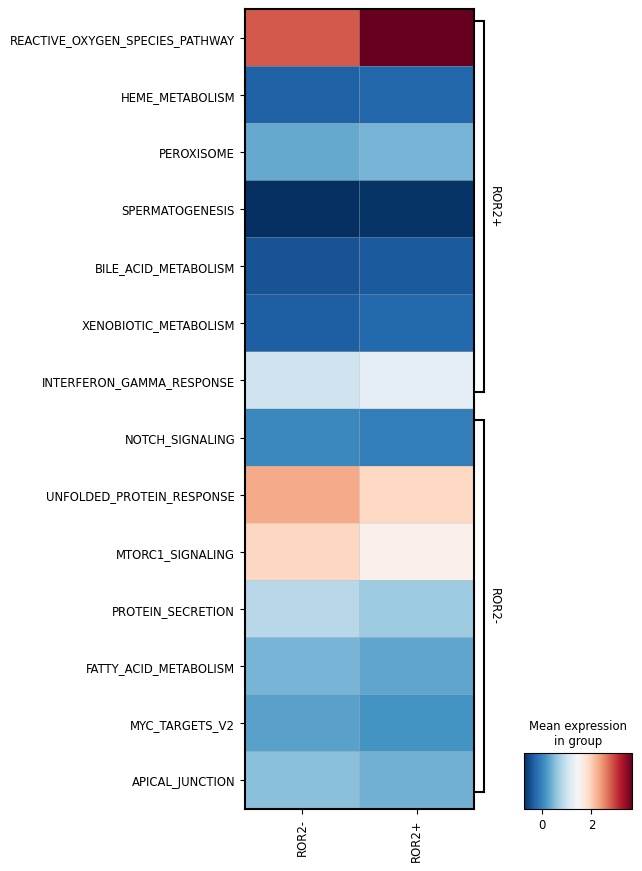

In [102]:
# Ensure WNT5A_group order is set
score.obs['ROR2_group'] = score.obs['ROR2_group'].astype(
    pd.CategoricalDtype(categories=["ROR2-", "ROR2+"], ordered=True)
)

# Plot heatmap rotated: genes on y-axis
sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,         # TFs of interest
    groupby="ROR2_group",
    dendrogram=False,                 # turn off clustering to preserve order
    #standard_scale="var",
    swap_axes=True,
    cmap="RdBu_r",
    #colorbar_title="Z-scaled scores",
    figsize=(5, 10),                  # taller figure for gene names
    save="ROR2_group_hallmark_scores_rotated.pdf"
)

# Step 6. ROR2 and CSC marker overlap

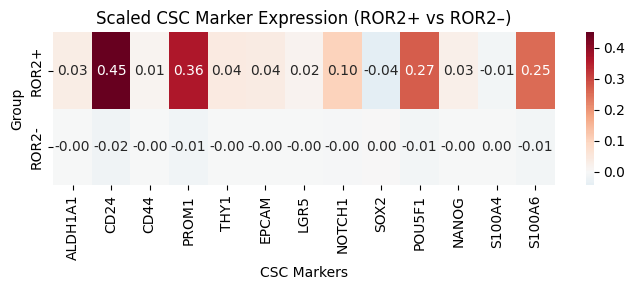

In [78]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Define CSC genes
csc_genes = ["ALDH1A1", "CD24", "CD44", "PROM1", "THY1", "EPCAM", "LGR5", "NOTCH1", "SOX2", "POU5F1", "NANOG", "S100A4", "S100A6"]

# Define ROR2+/- groups
adata.obs["ROR2_group"] = (adata[:, "ROR2"].X.toarray().flatten() > 0).astype(int)
adata.obs["ROR2_group"] = adata.obs["ROR2_group"].map({0: "ROR2-", 1: "ROR2+"})

# Extract the expression data
expr_df = adata.to_df()[csc_genes]

# Apply StandardScaler to the expression data
scaler = StandardScaler()
scaled_expr_df = pd.DataFrame(scaler.fit_transform(expr_df), columns=expr_df.columns, index=expr_df.index)

# Compute mean of scaled expression per group
scaled_expr_means = scaled_expr_df.groupby(adata.obs["ROR2_group"]).mean()

# Heatmap of scaled data
plt.figure(figsize=(7, 3))
sns.heatmap(scaled_expr_means, cmap="RdBu_r", annot=True, fmt=".2f", center=0)
plt.title("Scaled CSC Marker Expression (ROR2+ vs ROR2–)")
plt.ylabel("Group")
plt.xlabel("CSC Markers")
plt.tight_layout()
plt.savefig("Supp_CSC_ROR2_groups_scaled_heatmap.pdf", dpi=300)
plt.show()

# Step 7. FZD expression

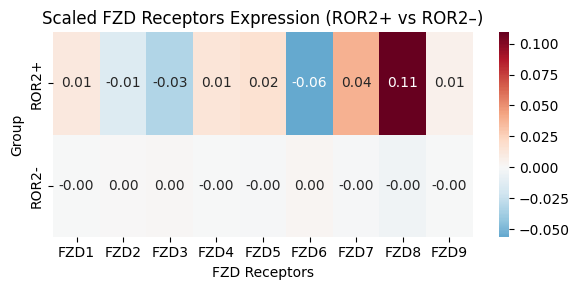

In [79]:
import numpy as np

fzd_genes = ["FZD1","FZD2","FZD3","FZD4","FZD5","FZD6","FZD7","FZD8","FZD9"]

# Define ROR2+/- groups
adata.obs["ROR2_group"] = (adata[:, "ROR2"].X.toarray().flatten() > 0).astype(int)
adata.obs["ROR2_group"] = adata.obs["ROR2_group"].map({0: "ROR2-", 1: "ROR2+"})

# Extract the expression data
expr_df = adata.to_df()[fzd_genes]

# Apply StandardScaler to the expression data
scaler = StandardScaler()
scaled_expr_df = pd.DataFrame(scaler.fit_transform(expr_df), columns=expr_df.columns, index=expr_df.index)

# Compute mean of scaled expression per group
scaled_expr_means = scaled_expr_df.groupby(adata.obs["ROR2_group"]).mean()

# Heatmap of scaled data
plt.figure(figsize=(6, 3))
sns.heatmap(scaled_expr_means, cmap="RdBu_r", annot=True, fmt=".2f", center=0)
plt.title("Scaled FZD Receptors Expression (ROR2+ vs ROR2–)")
plt.ylabel("Group")
plt.xlabel("FZD Receptors")
plt.tight_layout()
plt.savefig("Supp_CSC_ROR2_groups_fzd_scaled_heatmap.pdf", dpi=300)
plt.show()


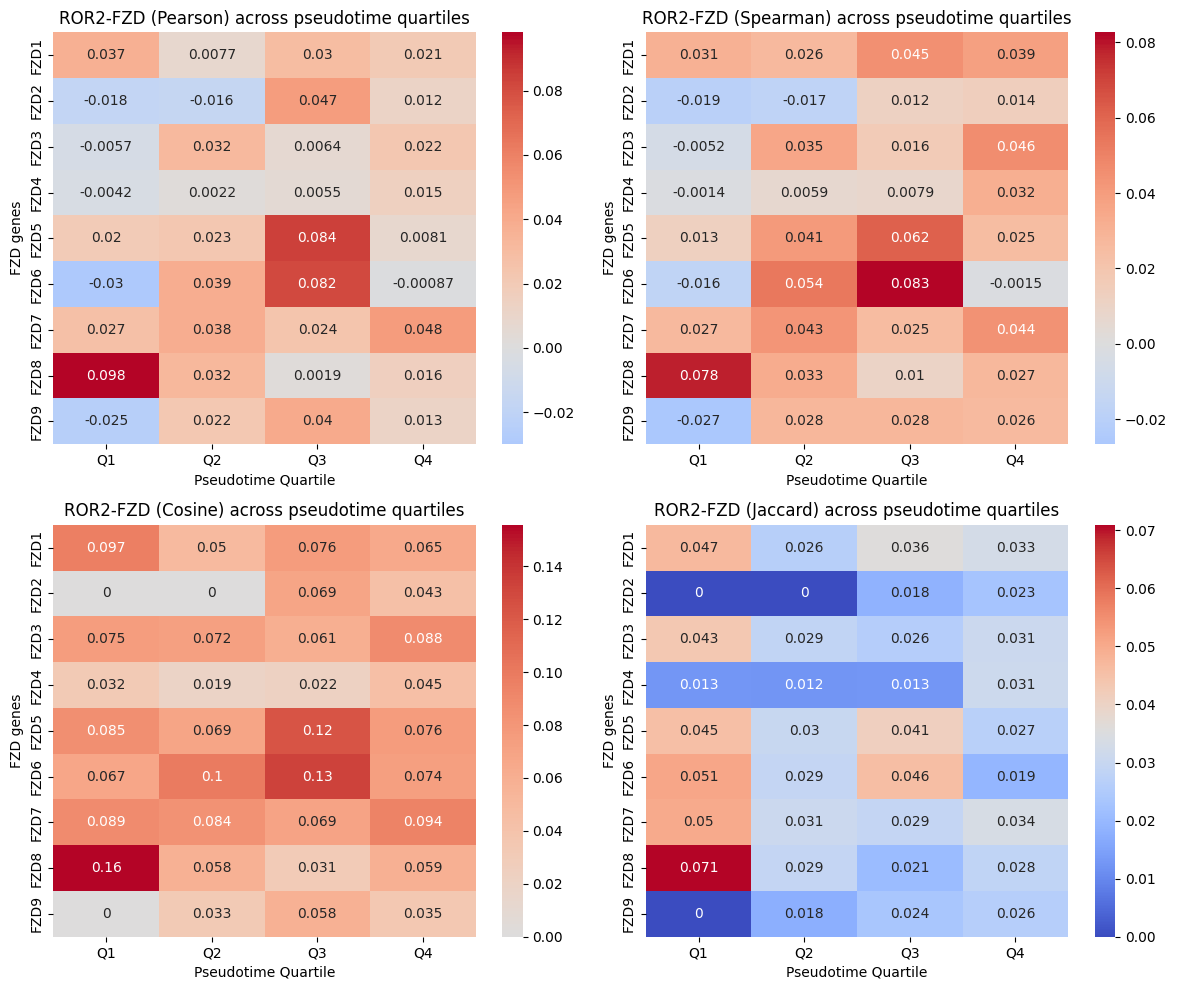

In [75]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Define FZD family genes
fzd_genes = ["FZD1","FZD2","FZD3","FZD4","FZD5","FZD6","FZD7","FZD8","FZD9"]

# ---------------------------
# Bin pseudotime into quartiles
# ---------------------------
adata.obs["ptime_bin"] = pd.qcut(adata.obs["ptime"], q=4, labels=["Q1","Q2","Q3","Q4"])

# ---------------------------
# Helper: compute all metrics per quartile
# ---------------------------
results = {"Pearson": {}, "Spearman": {}, "Cosine": {}, "Jaccard": {}}

for q in ["Q1","Q2","Q3","Q4"]:
    subset = adata[adata.obs["ptime_bin"] == q, :]
    sub_df = subset[:, ["ROR2"]+fzd_genes].X.toarray()
    df = pd.DataFrame(sub_df, columns=["ROR2"]+fzd_genes)

    # Pearson
    pearson = df.corr(method="pearson")["ROR2"].drop("ROR2")
    results["Pearson"][q] = pearson

    # Spearman
    spearman = df.corr(method="spearman")["ROR2"].drop("ROR2")
    results["Spearman"][q] = spearman

    # Cosine similarity (ROR2 vs. each FZD)
    cos_vals = cosine_similarity(df.T)  # pairwise gene-gene similarity
    cos_df = pd.DataFrame(cos_vals, index=df.columns, columns=df.columns)
    cosine = cos_df.loc["ROR2", fzd_genes]
    results["Cosine"][q] = cosine

    # Jaccard Index (binary expression > 0)
    binary = (df > 0).astype(int)
    jaccard = {}
    for g in fzd_genes:
        a = binary["ROR2"].values
        b = binary[g].values
        if np.sum(a | b) > 0:
            jaccard[g] = np.sum(a & b) / np.sum(a | b)
        else:
            jaccard[g] = 0
    results["Jaccard"][q] = pd.Series(jaccard)

# ---------------------------
# Convert to DataFrames
# ---------------------------
dfs = {}
for metric in results.keys():
    dfs[metric] = pd.DataFrame(results[metric])

# ---------------------------
# Plot heatmaps
# ---------------------------
plt.figure(figsize=(12, 10))
for i, metric in enumerate(dfs.keys(), 1):
    plt.subplot(2, 2, i)
    sns.heatmap(dfs[metric], annot=True, cmap="coolwarm", center=0 if metric!="Jaccard" else None)
    plt.title(f"ROR2-FZD ({metric}) across pseudotime quartiles")
    plt.xlabel("Pseudotime Quartile")
    plt.ylabel("FZD genes")

plt.tight_layout()
plt.savefig("Supp_ROR2_FZD_Pearson_Spearman_Cosine_Jaccard.pdf", dpi=300)
plt.show()
